In [31]:
import os
import tarfile
import urllib.request

from country_name import country_name_rus

CL =[ "Afganistan","China","CAR", "Ethiopia",
      "India", "Iran","KNDR", "Libya", "Morocco", "Sudan",
      "Syria", "Turkey", "Argentina", "DRK_Congo", "Burkina_Faso",
      "Niger", "Mali", "Senegal", "Egipet", "Gvineya", "Venesuela",
      "Algeria", "Zimbabve", "Tunis", "Boliviya", "Braziliya",
      "Yuar", "Burundi", "Ruanda", "Mongoliya", 'Pakistan', 
     "Chili", 'Bangladesh', 'Benin', 'Gabon', 'Laos', 'Chad' , 
     'Keniya', 'Indoneziya','Iordaniya', 'Irak', 'Kambodzha', 'Kuba',
     'Tailand','Urugvay', 'Kamerun', 'Madagaskar', 'Mozambik', 'Yaponiya',
     'Mexico', 'Oae','Saudovskaya_araviya', 'Yemen', 'Pakistan', 'Laos', 'RK_Congo',
     'angola', 'belorussiya', 'litva', 'franciya', 'botsvana', 'vengriya',
     'italiya', 'germaniya' , 'palestina', 'izrail', 'tayvan', 'tanzaniya',
     'ispaniya',  'livan', 'oman','paragvay', 'peru', 'portugaliya', 'ssha','kolumbiya', 'uganda', 'nigeriya',
     'gana', 'Respublika-koreya', 'ekvatorialnaya-gvineya', 'kot-d-ivuar',  'namibiya', 'zambiya','vetnam',  'myanma', 'filippiny'
    ]

DIR_PATH= {}
DOWNLOAD_ROOT = "D:/ML/"
print(DOWNLOAD_ROOT)
#DATASET_PATH = os.path.join("datasets", "Countries")
DATASET_PATH = os.path.join("datasets", "Countries_V3")

for item in CL:
    DIR_PATH[country_name_rus[item]] = os.path.join(DATASET_PATH, item)
    
filenames = {}
for items in DIR_PATH.keys():   
    filenames[items] = [name for name in sorted(os.listdir(DIR_PATH[items])) ] 
    print(items)

D:/ML/
Афганистан
КНР
Центрально-Африканская Республика
Эфиопия 
Индия
Иран
КНДР
Ливия
Морокко
Судан
Сирия
Турция
Аргентина
ДРК (Конго)
Буркина-Фасо
Нигер
Мали
Сенегал
Египет
Гвинея
Венесуэла
Алжир
Зимбабве
Тунис
Боливия
Бразилия
ЮАР
Бурунди
Руанда
Монголия
Пакистан
Чили
Бангладеш
Бенин
Габон
Лаос
Чад
Кения
Индонезия
Иордания
Ирак
Камбоджа
Куба
Таиланд
Уругвай
Камерун
Мадагаскар
Мозамбик
Япония
Мексика
ОАЭ
Саудовская Аравия
Йемен
Республика Конго
Ангола
Беларусь
Литва
Франция
Ботсвана
Венгрия
Италия
Германия
Палестина
Израиль
КНР (Тайвань)
Танзания
Испания
Ливан
Оман
Парагвай
Перу
Португалия
США
Колумбия
Уганда
Нигерия
Гана
Южная Корея
Экваториальная Гвинея
Кот-д'Ивуар
Намибия
Замбия
Вьетнам
Мьянма
Филиппины


In [32]:
len(country_name_rus.keys())

85

In [33]:
stemming=False # Stemming control
if stemming:
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer("russian")

In [34]:
from stop_words_ru import ru_stopwords

In [35]:
load_from_DB = True # True - Загрузка БД из json файла
                        # False - Пересборка  json файла из отдельных текстовых файлов

In [36]:
from charset_normalizer import from_path
import string

def remove_chars_from_text(text, chars):
    # return "".join([ch for ch in text if ch not in chars])
    content = ''
    for ch in text:
        if ch not in chars:
            content = content + ''.join(ch)
        else:
            content = content + ''.join(' ')
    return content

import re

def remove_emojis(data):
    emoj = re.compile("["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        u"\U00002500-\U00002BEF"  # chinese char
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        u"\U0001f926-\U0001f937"
        u"\U00010000-\U0010ffff"
        u"\u2640-\u2642" 
        u"\u2600-\u2B55"
        u"\u200d"
        u"\u23cf"
        u"\u23e9"
        u"\u231a"
        u"\ufe0f"  # dingbats
        u"\u3030"
                      "]+", re.UNICODE)
    return re.sub(emoj, ' ', data)
spec_chars = string.punctuation + '\r' + '\n\xa0«»\t—…' 

def clean_text (post_text):    
    text_post = re.sub(r'https?:\/\/.*[\r\n]*', ' ', post_text, flags=re.MULTILINE)
    text_post = re.sub(r'#[^\s|\n]+', ' ', text_post)
    text_post = remove_emojis(text_post)
    text_post = text_post.replace('Тут была французская Западная Африка | Подписаться', ' ')
    text_post = text_post.replace('Африканская инициатива | Подписаться', ' ')
    text_post = text_post.replace('@sex_drugs_kahlo — латиноамериканское счастье [нет]', ' ')
    text_post = text_post.replace('Подписаться | Обратная связь', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('  ', ' ')
    text_post = text_post.replace('/Синьхуа/', ' ')
    text_post = text_post.replace('[Full Text]', ' ')
    return text_post

import time
import random
import codecs, json
from datetime import datetime

def json_cleaning_stemm (json_file_name):
    with open(json_file_name, encoding='utf-8') as json_file:
        article_data = json.load(json_file)
    result_data = {}   
    for item in article_data.keys():
        x_temp = []
        content = str(article_data[item]['text']).lower()
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token) > 2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    # print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
    
        content = ' '.join(filtered_words)   
        result_data [item] = {'text': content, 'country': article_data[item]['country']}
    try: 
        with codecs.open('{}_cleaning_stemm.json'.format(json_file_name[:-5]), 'w', encoding='utf-8') as f:
             f.write(json.dumps(result_data, sort_keys = True, ensure_ascii=False))    
    except Exception as ex:
        print(ex)
    return


In [37]:
import pandas as pd 
    #Reading the JSON File 
x_temp = []
y_temp = []

if load_from_DB:
    json_cleaning_stemm ('Country_DB_V4_29-01-2025.json')     
    df = pd.read_json('Country_DB_V4_29-01-2025_cleaning_stemm.json').T
else:
    for item in filenames.keys():
        post_temp=[]
        for names in filenames[item]:
            content = str(from_path(DIR_PATH[item]+"\\"+names).best())            
            content = clean_text(content)                
            x_temp.append(content)
            y_temp.append(item)
    try:
        article_data ={}
        for article_id in range(0, len(x_temp)):
            #print (article_id)
            article_data [article_id] = {'text': x_temp [article_id], 'country': y_temp [article_id]}
        time = datetime.now().strftime("%d-%m-%Y")
        with codecs.open('Country_DB_V4_{}.json'.format(time), 'w', encoding='utf-8') as f:
             f.write(json.dumps(article_data, sort_keys = True, ensure_ascii=False))
        json_cleaning_stemm ('Country_DB_V4_{}.json'.format(time))     
        df = pd.read_json('Country_DB_V4_{}_cleaning_stemm.json'.format(time)).T
    except Exception as ex:
        print(ex)

json_cleaning_stemm ('Country_DB_V4_checked_21-08-2025.json')
df_checked = pd.read_json('Country_DB_V4_checked_21-08-2025_cleaning_stemm.json').T
MergeJson = pd.concat([df, df_checked], axis=0)
        



In [38]:
df_checked

,country,text
0,Судан,судане сезонных наводнений пострадало тысяч че...
1,Судан,срыв американо суданских переговоров каире пер...
10,Турция,глава суверенного совета судана встретился пре...
100,Ирак,президент ирана масуд пезешкиан правительствен...
1000,КНР,китайско американская рабочая группа финансовы...
...,...,...
995,Иран,возобновление работы иранского посольства сири...
996,Южная Корея,отстраненному власти президенту грозят новые в...
997,КНР,цзиньпин призвал провинцию хайнань вписать соб...
998,КНР,китае продлили срок безвизового транзитного пр...


In [39]:
df

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
9995,Руанда,сми руанда обвинила конго причастности похищен...
9996,Руанда,африканский союз выразил беспокойство кризисом...
9997,Руанда,церковь англии раскритиковала планы правительс...
9998,Руанда,трасс подтвердила британия начнет отправлять н...


In [40]:
len(set(MergeJson["country"].tolist()))

85

In [41]:
for country in set(MergeJson["country"].tolist()): 
    sum = MergeJson[MergeJson["country"]==country]['text'].count()
    print(f'{country} - {sum} ')

Перу - 210 
Индия - 1479 
Саудовская Аравия - 226 
Таиланд - 78 
Турция - 1222 
Танзания - 233 
Республика Конго - 209 
Габон - 98 
Иордания - 222 
Венгрия - 213 
Гвинея - 142 
ОАЭ - 397 
Филиппины - 166 
Индонезия - 191 
Вьетнам - 334 
Сирия - 148 
Израиль - 220 
Южная Корея - 258 
Чили - 85 
ЮАР - 104 
Монголия - 92 
Кот-д'Ивуар - 242 
Мадагаскар - 105 
Мали - 356 
КНР (Тайвань) - 212 
Афганистан - 471 
Ирак - 69 
Бенин - 231 
Пакистан - 263 
Франция - 211 
Португалия - 205 
Экваториальная Гвинея - 192 
Ливан - 205 
Буркина-Фасо - 246 
Кения - 243 
Камбоджа - 71 
Нигерия - 275 
Алжир - 220 
Беларусь - 225 
Мьянма - 272 
Куба - 234 
Намибия - 181 
Аргентина - 158 
Эфиопия  - 450 
Уругвай - 48 
Ботсвана - 106 
Чад - 253 
Нигер - 113 
Руанда - 220 
КНР - 2472 
Мексика - 1086 
Центрально-Африканская Республика - 628 
Гана - 249 
Египет - 282 
КНДР - 455 
Иран - 670 
Испания - 202 
США - 293 
Зимбабве - 207 
Япония - 294 
Колумбия - 201 
Морокко - 731 
Палестина - 229 
ДРК (Конго) - 545 


In [42]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
if load_from_DB:
    X = np.array(MergeJson['text'], dtype=object)
    y = np.array(MergeJson['country'])
else:
    X = np.array(x_temp, dtype=object)
    y = np.array(y_temp)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
len(X)

25470

In [44]:
len(y)

25470

In [45]:
MergeJson

,country,text
0,Афганистан,источники мест пишут вертолёт таджикистана отс...
1,Афганистан,присутствие запада афганистане минимальным под...
10,Афганистан,руководстве афганского талибана запрещенная те...
100,Афганистан,россия направила афганистан спецборт гуманитар...
1000,КНР,офиса казахско китайской компании cnpc актобем...
...,...,...
995,Иран,возобновление работы иранского посольства сири...
996,Южная Корея,отстраненному власти президенту грозят новые в...
997,КНР,цзиньпин призвал провинцию хайнань вписать соб...
998,КНР,китае продлили срок безвизового транзитного пр...


In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,5), min_df=6)
print (tfidf)
#tfidf= CountVectorizer(max_features=20000)
X_train_transformed = tfidf.fit_transform(X_train)
#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf = DecisionTreeClassifier()
rf.fit(X_train_transformed, y_train)

y_pred = rf.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf, X_train_transformed, y_train, scoring='f1_macro'))    

TfidfVectorizer(max_features=20000, min_df=6, ngram_range=(1, 5))
[CV] END ................................ score: (test=0.778) total time=  15.1s
[CV] END ................................ score: (test=0.777) total time=  15.5s
[CV] END ................................ score: (test=0.761) total time=  15.4s
0.7718324078748108
[0.77762199 0.78238923 0.78323051 0.77425687 0.77251052]
[0.74043644 0.74353185 0.7477636  0.73990983 0.73436266]


In [47]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf.fit(X_test_transformed, y_test)

y_pred = rf.predict(X_test_transformed)

print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_pred, average='weighted')))
print("Recall: {:.2f}%".format(100 * recall_score(y_test, y_pred, average='weighted')))

Precision: 98.60%
Recall: 98.48%


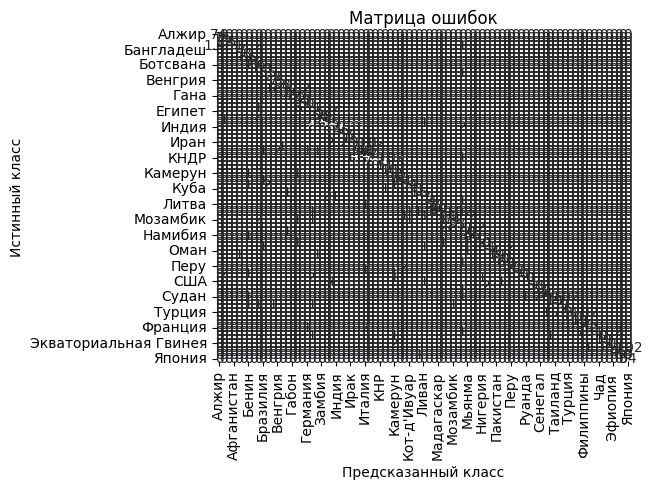

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
from sklearn.metrics import confusion_matrix
import pandas as pd
# Создать матрицу ошибок
matrix = confusion_matrix(y_test, y_pred)
# Создать структуру DataFrame библиотеки pandas
dataframe = pd.DataFrame(matrix, index=rf.classes_, columns=rf.classes_)
# Создать тепловую карту
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")
plt.title("Maтpицa ошибок")
plt.tight_layout()
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.show()

In [49]:
from sklearn.ensemble import RandomForestClassifier
#from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,5), min_df=6)
X_train_transformed = tfidf.fit_transform(X_train)

#rf = DecisionTreeClassifier(max_depth=depth , min_samples_leaf=50)
rf_RandomForest = RandomForestClassifier(random_state=3, n_jobs=-1, class_weight="balanced", oob_score=True, max_depth = 120, min_samples_split=12)
rf_RandomForest.fit(X_train_transformed, y_train)

y_pred = rf_RandomForest.predict_proba(X_train_transformed)[:, 1]
score = cross_val_score(rf_RandomForest, X_train_transformed, y_train, cv=3, verbose=3)
print(score.mean())
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='accuracy'))
print(cross_val_score(rf_RandomForest, X_train_transformed, y_train, scoring='f1_macro')) 
print(rf_RandomForest.oob_score_)

[CV] END ................................ score: (test=0.841) total time=   2.1s
[CV] END ................................ score: (test=0.846) total time=   2.0s
[CV] END ................................ score: (test=0.843) total time=   2.0s
0.8432890235010376
[0.83875491 0.84913068 0.8418396  0.84744812 0.84516129]
[0.81674323 0.82808488 0.81761988 0.82323084 0.82166008]
0.839867631387066


In [50]:
from sklearn.metrics import precision_score, recall_score

X_test_transformed = tfidf.transform(X_test)

rf_RandomForest.fit(X_test_transformed, y_test)

y_pred_RandomForest = rf_RandomForest.predict(X_test_transformed)

print("Precision: {:.2f}%".format(100 * precision_score(y_test, y_pred_RandomForest, average='weighted')))
print("Recall: {:.2f}%".format(100 * recall_score(y_test, y_pred_RandomForest, average='weighted')))

Precision: 96.08%
Recall: 95.43%


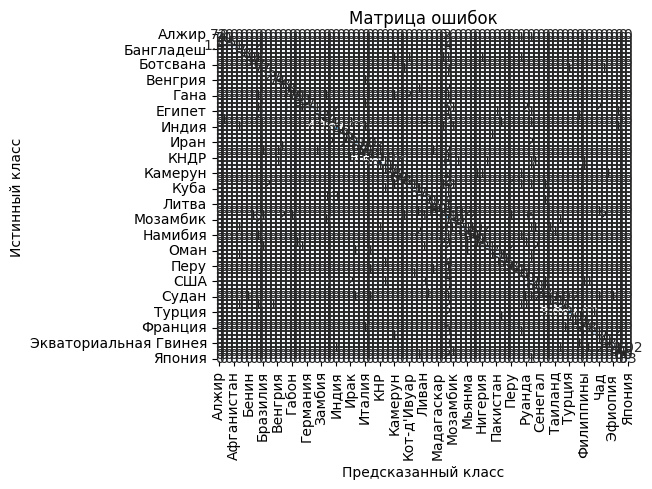

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns #pip install seaborn
from sklearn.metrics import confusion_matrix
import pandas as pd
# Создать матрицу ошибок
matrix = confusion_matrix(y_test, y_pred_RandomForest)
# Создать структуру DataFrame библиотеки pandas
dataframe = pd.DataFrame(matrix, index=rf_RandomForest.classes_, columns=rf_RandomForest.classes_)
# Создать тепловую карту
sns.heatmap(dataframe, annot=True, cbar=None, cmap="Blues")
plt.title("Maтpицa ошибок")
plt.tight_layout()
plt.ylabel("Истинный класс")
plt.xlabel("Предсказанный класс")
plt.show()

In [52]:
impoгtances = rf_RandomForest.feature_importances_
feature_imp_df = pd.DataFrame({'Word': tfidf.get_feature_names_out(), 'Importance': impoгtances}).sort_values('Importance', ascending=False) 
print(feature_imp_df[:50])

              Word  Importance
742        бурунди    0.011002
2714      зимбабве    0.009397
5642          перу    0.008761
9669          чили    0.008016
9990        японии    0.007987
2502        замбии    0.007692
663        боливии    0.007467
3741         ливии    0.007262
3383      колумбии    0.007211
4419       намибии    0.007208
3886       марокко    0.006933
9899       эфиопии    0.006924
4273      монголии    0.006676
8731      танзании    0.006590
490      бангладеш    0.006526
2901         индии    0.006408
6075    португалии    0.006367
293         анголы    0.006339
3854          мали    0.006307
9003        турции    0.006225
3262         кении    0.006219
4694       нигерии    0.006190
9523           цар    0.006172
2923     индонезии    0.006083
3836   мадагаскаре    0.006075
3773         литвы    0.005932
9190       уругвая    0.005780
3018      иордании    0.005769
9064        уганды    0.005658
8979        тунисе    0.005577
1475      вьетнама    0.005539
9915    

In [53]:
with open('./datasets/feature_importances_nostamm.txt', "w", encoding="utf-8") as some_file:
    some_file.write(feature_imp_df.to_string())

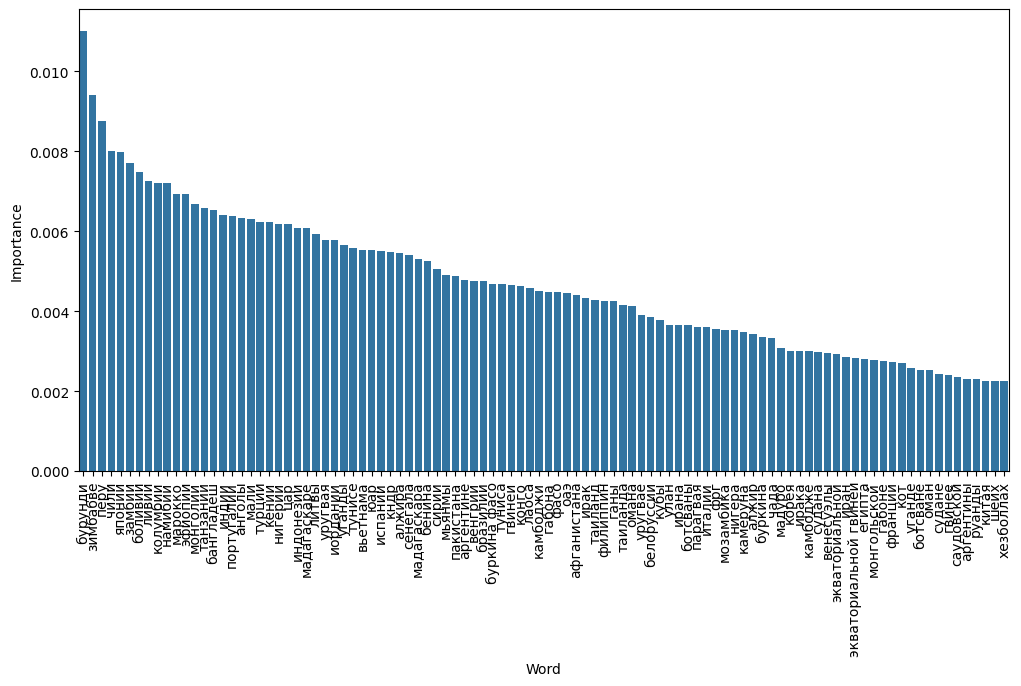

In [54]:
import pandas as pd
import seaborn as sns
plt.figure(figsize=(12, 6))
ax = sns.barplot(x="Word", y="Importance", data=feature_imp_df[:100])

ax.tick_params(axis='x', labelrotation=90)
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
# ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


In [55]:
new_text = ['Нигер последовал примеру Мали, разорвав связи с Украиной после того, как пресс-секретарь разведывательного агентства Министерства обороны Украины признал, что Украина оказывала поддержку повстанцам, которые убили малийских вооруженных сил и российских агентов 25-27 июля в Тинзауатене, на севере Мали, недалеко от границы с Алжиром.Посол Украины в Сенегале также выразил безоговорочную поддержку малийским повстанцам, что привело к вызову посла в МИД Сенегала.',
            'Еще новости афганской промышленности. В Кандагаре спустя 18 лет возобновила работу текстильная фабрика. Официальные лица говорят, что они отремонтировали оборудование на фабрике за шесть месяцев, сообщают афганское СМИ. По словам работников фабрики, с возобновлением работы фабрики созданы рабочие места. 69-летний Мохаммад, проработавший на текстильной фабрике в Кандагаре значительное время, рад вернуться на работу.',
           'Накопленное непонимание между Китаем и США не может быть решено лишь одним подобным изящным жестом. Страны расходятся по широкому кругу вопросов, санкционный механизм против Китая не ослаблен. Поэтому отправка панд – это скорее демонстрация миролюбивой позиции Китая в противовес США.',
            'В Алжире, как правило, на похоронах мужчины сидят около дома, хорошо, если есть сад или терраса, а женщины в доме, надеть платок женщина должна обязательно, даже если в обычной жизни она не покрывает голову. Если покойный жил в квартире, то прямо во дворе ставят стулья и шатры со столами для мужчин.Готовят либо нанятые кухарки, либо родственницы покойного. Пока составляла пост от подруги услышала,что в их семье часто еду приносят те, кто приходит в дом, а готовить должны невестки, а не дочери умершего. Мой муж сказал, что это совершенно необязательно, на похоронах его бабушки готовили только её дочери, это было их желание и никаких особых правил на счёт этого нет. Обязательного блюда на поминки в Алжире нет. Народ приходит помянутьот трех дней до недели, если у человека была большая семья и много знакомых!Кормят традиционными блюдами: суп-шорба, кус-кус/беркукес/тлитли с мясом и т.д.Могилу посещают каждое утро, в течении трех дней. Через 40 дней устанавливают небольшое надгробие, никаких памятников,вычурных элементов. На надгробии имя, фамилия, даты рождения и смерти, фотографий нет. Вроде бы написала всё, что знала. Задавайте вопросы в комментариях, если таковые имеются.',
            'Сегодня в Венесуэле проходят президентские выборы. Мой коллега Дмитрий Морозов рассуждает, как их итоги могут повлиять на дальнейший путь страны. Вот самое важное из его статьи.📍В выборах один тур, участвуют десять кандидатов, однако только двое имеют реальные шансы на победу: действующий президент Николас Мадуро и Эдмундо Гонсалес Уррутия, кандидат от Единой демократической платформы, объединяющей наиболее значимые оппозиционные партии.',
            'С возвращением Трампа в Белый дом «тропический Трамп» Жаир Болсонару осмелел и заявил, что, будь он сейчас президентом Бразилии, вышел бы из БРИКС. И попросился бы в Североамериканское соглашение о свободной торговле (NAFTA), к США, Канаде и Мексике. Он даже предложил переименовать его в Американское соглашение о свободной торговле (AFTA). Очень уж Болсонару раздражает, что теперь в БРИКС входят Куба и Боливия (правда, они не входят, а являются странами-партнерами. Но спасибо, хоть Испанию как страну БРИКС не перечислил). Только вот когда Болсонару действительно был президентом Бразилии, он из БРИКС не выходил. Хотя многие тогда и пророчили.',
            'Почему слова Трампа о присоединении Гренландии надо воспринимать всерьёз — статья Максима Сучкова @postamerica: • Присоединение территорий — обычный способ наращивания государствами мощи. Для лидеров — это ещё и возможность запомниться потомкам, войти в историю. Эгоцентрист-государственник Трамп желает и первого, и второго. Как политик-националист, он стремится укрепить американские позиции в «ближнем зарубежье» США. Как «политик на втором сроке», он хочет, чтобы каждое решение по этой части было стратегическим и долгосрочным, «оставляло наследие». А специфический образ мысли Трампа требует, чтобы это наследие обязательно было грандиозным. • В случае с заявлениями Трампа по поводу Гренландии партнёры Америки находятся в замешательстве: зачем забирать земли у союзников, да ещё в тот момент, когда они третий год подряд убеждают мир в том, что так нельзя и за это надо наказывать? Особенно негодуют французы и датчане, по иронии судьбы, некогда продавшие Соединённым Штатам свои заморские территории: французы — Луизиану в 1803 году (за $15 млн), датчане — Датскую Вест-Индию (современные Американские Виргинские Острова) в 1917 году (за $25 млн). • Трампа, очевидно, не сильно заботит эта реакция. Но ему, вероятно, хочется, чтобы процедура присоединения острова была оформлена красиво — с соблюдением внешних приличий и юридических правил. Провернуть всё это американцам вполне по силам: нация коммерсантов и юристов, по части способности покупать, продавать и обрамлять это изысканной правовой рамкой, равных себе не имеет. • Судя по всему, Трамп нацелен именно на этот сценарий: Трамп-младший слетал в Гренландию, где, по слухам, прощупывал местные лояльные Америке круги, выясняя их готовность организовать референдум о вхождении в состав США; республиканские законодатели в Конгрессе изучают варианты правового оформления этой инициативы; экономисты рассчитывают стоимость возможной сделки — она варьируется в диапазоне от $12,5 млрд до $77 млрд. Параллельно прорабатывается и вариант с долгосрочной арендой острова. • С середины XIX века Гренландия рассматривается США как ключ к контролю над Арктикой. Сегодня Арктика — одна из главных арен великодержавного соперничества. Традиционный инструментарий усиления в этом регионе самих американцев — виртуозно использовать нормотворчество, регламентирующее пользование Арктикой, и стремиться увеличивать площади континентального шельфа. Это они делали задолго до Трампа. • Сам же Трамп убеждён: в то время как конкуренты США укреплялись, Байден и его команда на протяжении четырёх лет только и делали, что бездумно расточали ресурсы страны. Пришла пора собирать камни. Читать статью для @profilejournal'
           ]
x_temp = []
for post_temp in new_text:
        content = str(post_temp).lower()  
        content = remove_emojis(content)
        content = remove_chars_from_text(content, spec_chars)
        content = remove_chars_from_text(content, string.digits)
        for i in range(1, 10):
            content = content.replace('  ', ' ')
        filtered_words = []
        for token in content.split():
            if token not in ru_stopwords and len(token)>2:
                if stemming and token is not None:
                    filtered_words.append(stemmer.stem(token))
                    #print('{} -{}'.format(token,stemmer.stem(token)))
                else:
                    filtered_words.append(token)
                      
        content = ' '.join(filtered_words)  
        #if ngram_replace:
        #    for item in vocabl:
        #        if item.replace('_', ' ') in vocabl:
         #           content.replace(item.replace('_', ' '), item)
                    #print(item)                
        x_temp.append(content)
count = CountVectorizer(ngram_range=(1,5), vocabulary = set(tfidf.get_feature_names_out()))
#count = CountVectorizer(vocabulary = set(X_train_words))
X_t = count.transform(x_temp)
#print(count.vocabulary_)
accuracy = rf_RandomForest.predict(X_t)
print (accuracy)

['Сенегал' 'Уругвай' 'КНР' 'Алжир' 'Венесуэла' 'Бразилия' 'США']


In [56]:
probabilities = rf_RandomForest.predict_proba(X_t)
for i, prob in enumerate(rf_RandomForest.predict(X_t)):
    print(f"Sample {i}")
    for ix , probx in enumerate(rf_RandomForest.classes_):
        if probabilities[i][ix]>0.02:
            print(f" Class {probx}, Probability = {probabilities[i][ix]:.2f}")

Sample 0
 Class Мали, Probability = 0.29
 Class Нигер, Probability = 0.11
 Class Сенегал, Probability = 0.50
Sample 1
 Class Замбия, Probability = 0.02
 Class КНР, Probability = 0.04
 Class Мексика, Probability = 0.03
 Class Уругвай, Probability = 0.08
 Class Чили, Probability = 0.03
Sample 2
 Class КНР, Probability = 0.43
 Class Мексика, Probability = 0.02
 Class Парагвай, Probability = 0.03
 Class США, Probability = 0.04
Sample 3
 Class Алжир, Probability = 0.24
 Class Аргентина, Probability = 0.04
 Class Мексика, Probability = 0.03
Sample 4
 Class Венесуэла, Probability = 0.58
 Class Мексика, Probability = 0.02
 Class Парагвай, Probability = 0.03
 Class Сенегал, Probability = 0.02
Sample 5
 Class Боливия, Probability = 0.14
 Class Бразилия, Probability = 0.38
 Class Куба, Probability = 0.07
 Class Мексика, Probability = 0.07
 Class США, Probability = 0.11
Sample 6
 Class Германия, Probability = 0.03
 Class Индия, Probability = 0.03
 Class КНР, Probability = 0.04
 Class Мексика, Prob

In [57]:
rf_RandomForest.classes_

array(['Алжир', 'Ангола', 'Аргентина', 'Афганистан', 'Бангладеш',
       'Беларусь', 'Бенин', 'Боливия', 'Ботсвана', 'Бразилия',
       'Буркина-Фасо', 'Бурунди', 'Венгрия', 'Венесуэла', 'Вьетнам',
       'Габон', 'Гана', 'Гвинея', 'Германия', 'ДРК (Конго)', 'Египет',
       'Замбия', 'Зимбабве', 'Израиль', 'Индия', 'Индонезия', 'Иордания',
       'Ирак', 'Иран', 'Испания', 'Италия', 'Йемен', 'КНДР', 'КНР',
       'КНР (Тайвань)', 'Камбоджа', 'Камерун', 'Кения', 'Колумбия',
       "Кот-д'Ивуар", 'Куба', 'Лаос', 'Ливан', 'Ливия', 'Литва',
       'Мадагаскар', 'Мали', 'Мексика', 'Мозамбик', 'Монголия', 'Морокко',
       'Мьянма', 'Намибия', 'Нигер', 'Нигерия', 'ОАЭ', 'Оман', 'Пакистан',
       'Палестина', 'Парагвай', 'Перу', 'Португалия', 'Республика Конго',
       'Руанда', 'США', 'Саудовская Аравия', 'Сенегал', 'Сирия', 'Судан',
       'Таиланд', 'Танзания', 'Тунис', 'Турция', 'Уганда', 'Уругвай',
       'Филиппины', 'Франция', 'Центрально-Африканская Республика', 'Чад',
       'Чили'

In [58]:
import pickle
from datetime import datetime

time = datetime.now().strftime("%d-%m-%Y")

with open('country_post-model_ngram_rf_tfidf_V4_024_{}_lowRAM_nostamm.bin'.format(time), 'wb') as f_out:
    pickle.dump([rf_RandomForest, tfidf.get_feature_names_out()], f_out)